# Gradient Descent Sparsification — Free Edges

Minimize `||d_inf_orig - d_inf_sparse||_p` by freely placing edges anywhere in the graph.
Upper-triangle parameters `M_logit` map to **nonnegative link strengths** `P = softplus(M_logit)` (can exceed 1). The loss uses pseudo-distances `log(1 + P)` in the resolvent kernel (positive, smooth). At extraction, `P` is treated as **proximity** on edges (still max-normalized afterward for `beta_scale`). L1 encourages small `P` off the selected support; we keep the top-`n_edges` entries by value.

In [108]:
import sys
import importlib.util
from pathlib import Path

def _find_repo_root():
    cwd = Path.cwd().resolve()
    for base in (cwd, cwd / "notebooks", *cwd.parents):
        if (base / "src" / "python" / "graph_sparsification").is_dir():
            return base
    raise RuntimeError(
        "Could not locate src/python/graph_sparsification. "
        "Run the notebook with the working directory set to the repo or notebooks/."
    )

_ROOT = _find_repo_root()
sys.path.insert(0, str(_ROOT / "src" / "python"))

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import igraph as ig
from scipy.linalg import solve_triangular
from scipy import sparse

from graph_sparsification.generators import configuration_model, wsbm
from graph_sparsification.sir import sir_monte_carlo
from graph_sparsification.sparsifiers import (
    distance_to_proximity,
    effective_resistance_sparsify,
    metric_backbone,
    metric_backbone_rescaled,
    proximity_to_distance,
    to_proximity,
)


def is_metric_backbone_cpp_available():
    return False


def igraph_to_sparse_distance(G):
    n = G.vcount()
    W = sparse.lil_matrix((n, n), dtype=np.float64)
    for e in G.es:
        i, j = e.tuple
        d = float(e["distance_weight"])
        W[i, j] = d
        W[j, i] = d
    return sparse.csr_matrix(W)


def igraph_to_sparse_proximity(G):
    n = G.vcount()
    W = sparse.lil_matrix((n, n), dtype=np.float64)
    for e in G.es:
        i, j = e.tuple
        p = float(e["proximity_weight"])
        W[i, j] = p
        W[j, i] = p
    return sparse.csr_matrix(W)


def sparse_distance_to_igraph(W_dist):
    W_dist = sparse.triu(sparse.csr_matrix(W_dist, dtype=float), k=1)
    coo = W_dist.tocoo()
    n = int(W_dist.shape[0])
    edges = list(zip(coo.row.tolist(), coo.col.tolist()))
    if not edges:
        return ig.Graph(n=n, directed=False)
    G = ig.Graph(n=n, edges=edges, directed=False)
    d = np.asarray(coo.data, dtype=float)
    p = distance_to_proximity(d)
    G.es["distance_weight"] = d.tolist()
    G.es["proximity_weight"] = p.tolist()
    return normalize_proximity_weights(G)


def sparse_proximity_to_igraph(W_prox):
    W_prox = sparse.triu(sparse.csr_matrix(W_prox, dtype=float), k=1)
    coo = W_prox.tocoo()
    n = int(W_prox.shape[0])
    edges = list(zip(coo.row.tolist(), coo.col.tolist()))
    if not edges:
        return ig.Graph(n=n, directed=False)
    G = ig.Graph(n=n, edges=edges, directed=False)
    p = np.asarray(coo.data, dtype=float)
    d = proximity_to_distance(p)
    G.es["proximity_weight"] = p.tolist()
    G.es["distance_weight"] = d.tolist()
    return normalize_proximity_weights(G)


def normalize_proximity_weights(G):
    """Divide edge proximities by their max, recompute distances, store scale for SIR.

    Writes graph attribute ``beta_scale``: cumulative product of maxima used so that
    running SIR with ``beta * beta_scale`` and normalized weights recovers the
    original per-edge transmission scale (``beta * w`` before this step).
    """
    prev_scale = 1.0
    try:
        prev_scale = float(G["beta_scale"])
    except (KeyError, TypeError, ValueError):
        pass

    if G.ecount() == 0:
        G["beta_scale"] = prev_scale
        return G

    p = np.asarray(G.es["proximity_weight"], dtype=float)
    mx = float(np.max(p))
    if mx <= 0.0:
        G["beta_scale"] = prev_scale
        return G

    p = p / mx
    p = np.maximum(p, 1e-12)
    # Standard d = 1/p - 1 only for p <= 1; for p > 1 use 1/p as a nonnegative surrogate cost.
    d = np.where(p <= 1.0, proximity_to_distance(np.minimum(p, 1.0 - 1e-12)), 1.0 / p)
    G.es["proximity_weight"] = p.tolist()
    G.es["distance_weight"] = d.tolist()
    G["beta_scale"] = prev_scale * mx
    return G


def get_beta_scale(G):
    """Return ``beta_scale`` set by ``normalize_proximity_weights`` (max-prox factor); else 1.0."""
    try:
        s = float(G["beta_scale"])
        return s if s > 0.0 else 1.0
    except (KeyError, TypeError, ValueError):
        return 1.0


def get_metric_backbone_subgraph_cpp(G, n_threads=4):
    W_dist = igraph_to_sparse_distance(G)
    return sparse_distance_to_igraph(metric_backbone(W_dist))


def generate_wsbm(n, pi, B, rho_N=None, Lambda=None, seed=None, **kwargs):
    rng = np.random.default_rng(seed)
    pi = np.asarray(pi, dtype=float)
    k = len(pi)
    B = np.asarray(B, dtype=float).copy()
    if rho_N is not None:
        base = np.log(n) / n
        B *= rho_N / base
    W, _z = wsbm(n, k, pi, B, weight_distribution="exponential", Lambda=Lambda, rng=rng)
    return sparse_distance_to_igraph(W)


def generate_config_model(n, degree_distribution, weight_distribution, seed=None):
    rng = np.random.default_rng(seed)

    def deg_sampler(n_, rng_):
        d = np.asarray(degree_distribution(n_), dtype=int)
        return np.maximum(d, 1)

    def weight_sampler(m, rng_):
        return np.asarray(weight_distribution(m), dtype=float)

    W = configuration_model(n, deg_sampler, weight_sampler, rng=rng)
    return sparse_distance_to_igraph(W)


def compute_mse(p_orig, p_sparse, n_bootstrap=2000, rng=None):
    rng = np.random.default_rng(rng)
    p_orig = np.asarray(p_orig, dtype=float).ravel()
    p_sparse = np.asarray(p_sparse, dtype=float).ravel()
    diff2 = (p_orig - p_sparse) ** 2
    mse = float(np.mean(diff2))
    n = diff2.size
    if n == 0:
        return mse, (mse, mse)
    idx = rng.integers(0, n, size=(n_bootstrap, n))
    boots = diff2[idx].mean(axis=1)
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return mse, (float(lo), float(hi))


def run_sir_on_igraph(G, beta, gamma, patient_zeros, t_max, n_runs, seed, verbose=False, n_threads=1):
    W = igraph_to_sparse_proximity(G)
    r = sir_monte_carlo(
        W,
        beta,
        gamma,
        initial_infected=patient_zeros,
        n_runs=n_runs,
        t_max=t_max,
        rng=seed,
        use_cpp=is_sir_cpp_available(),
    )
    return r["infection_prob"], None, r["all_arrival_times"]


def run_pipeline(
    G_orig,
    sir_beta,
    sir_gamma,
    sir_patient_zeros,
    sir_t_max,
    sir_n_runs,
    seed,
    verbose=False,
):
    W_dist = igraph_to_sparse_distance(G_orig)
    W_prox = to_proximity(W_dist)
    W_mbb_dist = metric_backbone(W_dist)
    W_mbb_prox = to_proximity(W_mbb_dist)
    W_mbbr_prox = metric_backbone_rescaled(W_dist)
    n_edges = sparse.triu(W_mbb_dist, k=1).nnz
    if n_edges == 0:
        n_edges = max(1, sparse.triu(W_prox, k=1).nnz // 2)
    W_effr = effective_resistance_sparsify(W_prox, n_edges=n_edges, rng=seed)
    beta_eff = sir_beta * get_beta_scale(G_orig)
    mc_kw = dict(
        gamma=sir_gamma,
        initial_infected=sir_patient_zeros,
        n_runs=sir_n_runs,
        t_max=sir_t_max,
        rng=seed,
        use_cpp=is_sir_cpp_available(),
    )

    def probs(Wp):
        return sir_monte_carlo(Wp, beta_eff, **mc_kw)["infection_prob"]

    p_orig = probs(W_prox)
    p_mbb = probs(W_mbb_prox)
    p_mbbr = probs(W_mbbr_prox)
    p_effr = probs(W_effr)
    br = np.random.default_rng(seed)
    mse_mbb, mse_mbb_CI = compute_mse(p_orig, p_mbb, rng=br)
    mse_mbb_rescaled, mse_mbb_rescaled_CI = compute_mse(p_orig, p_mbbr, rng=br)
    mse_effr, mse_effr_CI = compute_mse(p_orig, p_effr, rng=br)
    if verbose:
        print("Pipeline done.")
    return {
        "infection_probs": {
            "orig": p_orig,
            "MBB": p_mbb,
            "MBB_rescaled": p_mbbr,
            "EffR": p_effr,
        },
        "MBB": sparse_distance_to_igraph(W_mbb_dist),
        "MBB_rescaled": sparse_proximity_to_igraph(W_mbbr_prox),
        "EffR": sparse_proximity_to_igraph(W_effr),
        "mse_mbb": mse_mbb,
        "mse_mbb_CI": mse_mbb_CI,
        "mse_mbb_rescaled": mse_mbb_rescaled,
        "mse_mbb_rescaled_CI": mse_mbb_rescaled_CI,
        "mse_effr": mse_effr,
        "mse_effr_CI": mse_effr_CI,
    }


def is_sir_cpp_available():
    return importlib.util.find_spec("graph_sparsification._sir_cpp") is not None


print("Imports OK")
print(f"MBB C++ available: {is_metric_backbone_cpp_available()}")
print(f"SIR C++ available: {is_sir_cpp_available()}")


Imports OK
MBB C++ available: False
SIR C++ available: True


## Utility function

In [109]:
def m_matrix_to_igraph(M_np, n_edges, use_proximity=False):
    """
    Convert M matrix (upper triangular) to igraph.
    If use_proximity=True: M[i,j] is proximity directly (may be > 1 after softplus GD).
    If use_proximity=False: M[i,j] = exp(-distance) → distance = -log(M).
    """
    n = M_np.shape[0]
    rows, cols = np.triu_indices(n, k=1)
    vals = M_np[rows, cols]

    top_idx = np.argsort(vals)[-n_edges:]
    keep = np.zeros(len(vals), dtype=bool)
    keep[top_idx] = True

    if use_proximity:
        M_vals = np.maximum(vals[keep], 1e-9)
        proximities = M_vals
        distances = np.where(
            proximities <= 1.0,
            (1.0 / proximities) - 1.0,
            1.0 / proximities,
        )
    else:
        M_vals = np.clip(vals[keep], 1e-9, 1 - 1e-9)
        distances = -np.log(M_vals)
        proximities = 1.0 / (distances + 1.0)

    edges = list(zip(rows[keep].tolist(), cols[keep].tolist()))
    G = ig.Graph(n=n, edges=edges, directed=False)
    G.es["proximity_weight"] = proximities.tolist()
    G.es["distance_weight"] = distances.tolist()
    return normalize_proximity_weights(G)

## Plotting helpers

In [110]:
def plot_adjacency_matrices_per_graph_order(graphs, names=None, weight_attr="proximity_weight", 
                                            reorder_by_communities=True, figsize=None, dpi=150):
    """
    Plot adjacency matrices for multiple graphs on one row.
    If reorder_by_communities=True, each graph is reordered by its own Louvain community structure.
    """
    n = len(graphs)
    if names is None:
        names = [f"G{i}" for i in range(n)]
    if figsize is None:
        figsize = (4 * n, 5)

    fig, axes = plt.subplots(1, n, figsize=figsize, dpi=dpi)
    axes = np.atleast_1d(axes).flatten().tolist()
    cmap = plt.cm.viridis.copy()
    cmap.set_under(color="gray", alpha=0.9)

    for ax, G, name in zip(axes, graphs, names):
        if reorder_by_communities:
            try:
                w = G.es[weight_attr] if weight_attr in G.es.attributes() else None
                cl = G.community_multilevel(weights=w)
            except Exception:
                cl = G.community_multilevel()
            order = np.lexsort((np.arange(G.vcount()), np.array(cl.membership)))
        else:
            order = np.arange(G.vcount())

        try:
            A = np.array(G.get_adjacency(attribute=weight_attr, default=0).data).astype(float)
        except (KeyError, TypeError):
            try:
                A = np.array(G.get_adjacency(attribute="weight", default=0).data).astype(float)
            except (KeyError, TypeError):
                A = np.array(G.get_adjacency().data).astype(float)
        A = A[np.ix_(order, order)]

        im = ax.imshow(A, cmap=cmap, aspect="equal", vmin=1e-10, interpolation="nearest")
        ax.set_title(f"{name} ({G.ecount()} edges)")
        node_label = "node id (reordered by clusters)" if reorder_by_communities else "node id"
        ax.set_xlabel(node_label)
        ax.set_ylabel("node id")
        cbar = plt.colorbar(im, ax=ax, extend="min")
        cbar.set_label(f"{weight_attr} (gray = no edge)")

    plt.tight_layout()
    plt.show()

def plot_matrices(matrices, names=None, title=None, vmin=0, log_scale=False):
    n = len(matrices)
    if names is None:
        names = [f"M{i}" for i in range(n)]

    fig, axes = plt.subplots(1, max(1, n), figsize=(4 * max(1, n), 5), dpi=300)
    axes = np.atleast_1d(axes).flatten().tolist()

    cmap = plt.cm.viridis.copy()
    cmap.set_under(color="gray", alpha=0.9)

    if title:
        fig.suptitle(title, fontsize=14)

    for ax, A, name in zip(axes, matrices, names):
        nnz = int(np.sum(A[np.triu_indices(A.shape[0], k=1)] > 0))
        norm = LogNorm(vmin=vmin) if log_scale else None
        imshow_kwargs = {"norm": norm} if log_scale else {"vmin": vmin}
        im = ax.imshow(A, cmap=cmap, aspect="equal", interpolation="nearest", **imshow_kwargs)
        ax.set_title(f"{name}", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        cbar = plt.colorbar(im, ax=ax, extend="min")
        cbar.set_label("value (gray = 0)", fontsize=7)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## Graph generation

Three 500-node graphs:
- **G1**: wSBM 3-block (moderate community structure)
- **G2**: Configuration model (exponential degree + weight)
- **G3**: wSBM 4-block strong (strong community structure)

G1_wSBM3: 500 nodes, 22596 edges, total_prox=9473.1459
G2_CM: 500 nodes, 6682 edges, total_prox=619.9586
G3_wSBM4: 500 nodes, 19957 edges, total_prox=5233.2097

Shortest and longest path:
G1_wSBM3: shortest=1.000089e-12, diameter=4.606624e-03
G2_CM: shortest=1.000089e-12, diameter=2.162259e+02
G3_wSBM4: shortest=1.000089e-12, diameter=1.107072e-02


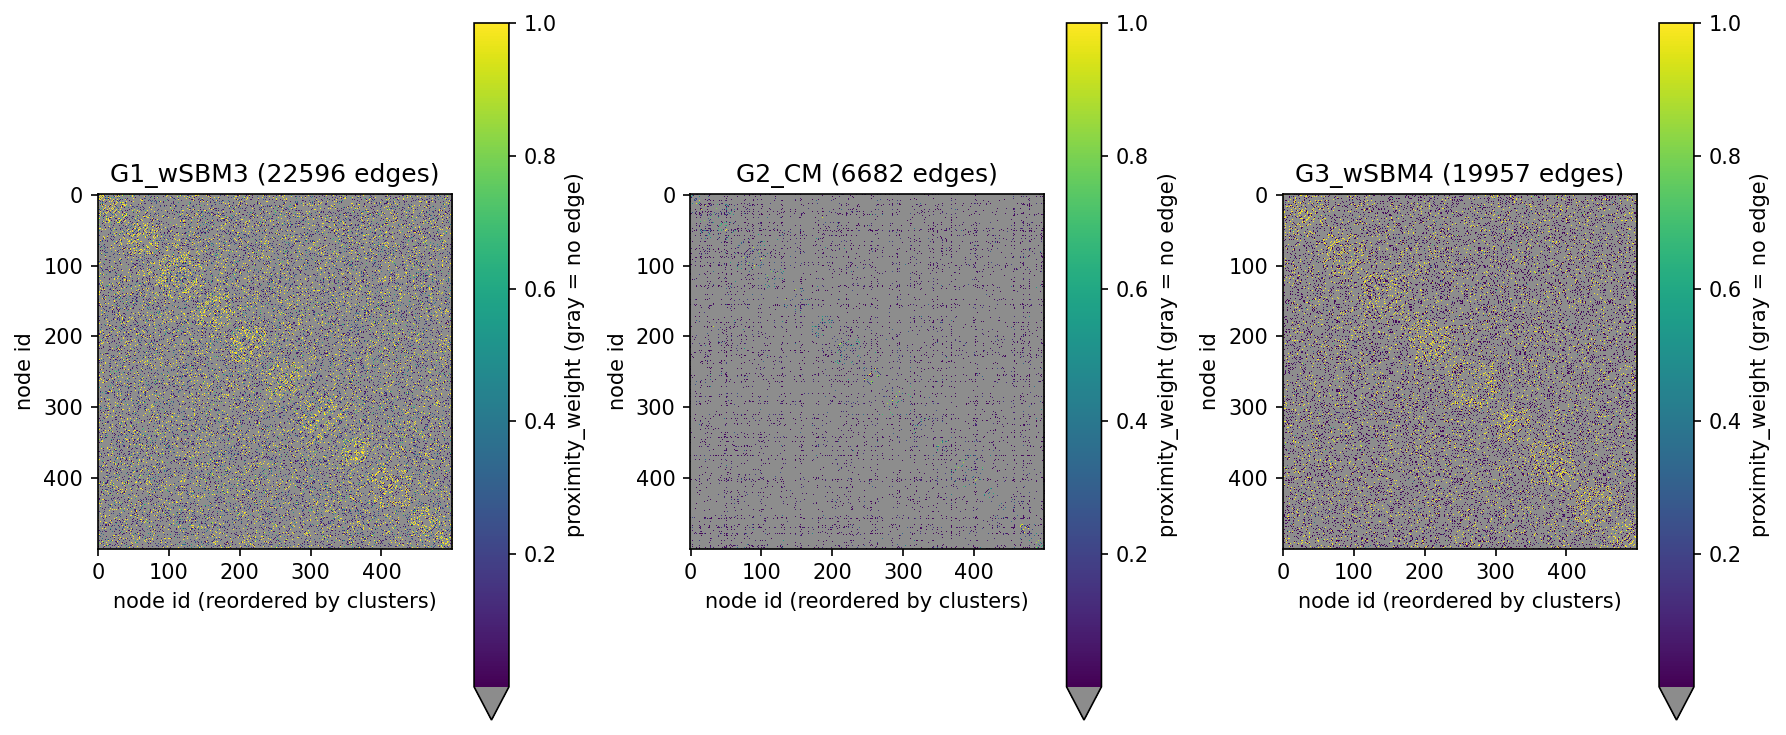

In [ ]:
seed = 42
n = 500

# G1: wSBM 3-block
k1, B_diag, B_off = 3, 8.0, 1.5
B1 = np.full((k1, k1), B_off)
np.fill_diagonal(B1, B_diag)
Lambda_diag, Lambda_off = 0.1, 200.0
Lambda1 = np.full((k1, k1), Lambda_off)
np.fill_diagonal(Lambda1, Lambda_diag)
G1 = generate_wsbm(n, np.ones(k1) / k1, B1, rho_N=4 * np.log(n) / n, Lambda=Lambda1, seed=seed)

# G2: Configuration model
G2 = generate_config_model(
    n=n,
    degree_distribution=lambda sz: np.random.default_rng(42).exponential(scale=30, size=sz).astype(int),
    weight_distribution=lambda m: np.random.default_rng(42).exponential(scale=30, size=m),
    seed=42,
)

# G3: wSBM 4-block strong
k3, B_diag, B_off = 4, 10.0, 1.0
B3 = np.full((k3, k3), B_off)
np.fill_diagonal(B3, B_diag)
Lambda_diag, Lambda_off = 0.01, 100.0
Lambda3 = np.full((k3, k3), Lambda_off)
np.fill_diagonal(Lambda3, Lambda_diag)
G3 = generate_wsbm(n, np.ones(k3) / k3, B3, rho_N=4 * np.log(n) / n, Lambda=Lambda3, seed=seed)

graphs = [("G1_wSBM3", G1), ("G2_CM", G2), ("G3_wSBM4", G3)]

for gname, G in graphs:
    print(f"{gname}: {G.vcount()} nodes, {G.ecount()} edges, total_prox={sum(G.es['proximity_weight']):.4f}")

print("\nShortest and longest path:")
for gname, G in graphs:
    weights = G.es["distance_weight"] if "distance_weight" in G.es.attributes() else None
    sp = np.array(G.distances(weights=weights))
    np.fill_diagonal(sp, np.nan)
    v = np.isfinite(sp) & (sp > 0)
    s, d = (np.nanmin(sp[v]), np.nanmax(sp[v])) if v.any() else (np.nan, np.nan)
    print(f"{gname}: shortest={s:.6e}, diameter={d:.6e}")

plot_adjacency_matrices_per_graph_order([G1, G2, G3], names=[g[0] for g in graphs], weight_attr="distance_weight")

## SIR parameters

In [112]:
sir_gamma = 1.0
sir_t_max = 100.0
sir_n_runs = 500
sir_patient_zeros = 0.01
sir_seed = 42
sir_beta_1, sir_beta_2, sir_beta_3 = 0.05, 1, 0.1
sir_betas = {"G1_wSBM3": sir_beta_1, "G2_CM": sir_beta_2, "G3_wSBM4": sir_beta_3}

## Gradient descent optimization function

In [113]:
def compute_loss_matrix(adjacency_matrix):
    # Make the adjacency matrix upper triangular
    n = adjacency_matrix.shape[0]
    mask = torch.triu(torch.ones(n, n, dtype=torch.bool, device=adjacency_matrix.device), diagonal=1)
    am_upper = torch.where(mask, adjacency_matrix, torch.zeros_like(adjacency_matrix))

    # Put to the exponential inverse
    base = 1.3
    exp_neg = torch.where(am_upper > 0.0, torch.pow(base, -am_upper), torch.zeros_like(adjacency_matrix))

    # Execute the infinite sum of powers
    I = torch.eye(n, dtype=adjacency_matrix.dtype, device=adjacency_matrix.device)
    X = torch.linalg.solve(I - exp_neg, I)
    tot_sum = X - I

    # Put the result to the logarithm
    log_sum = torch.where(tot_sum > 0.0, torch.log1p(tot_sum), torch.zeros_like(adjacency_matrix))

    return log_sum


def compute_loss(sparse_matrix, target_d_inf, norm_p):
    d_inf_sparse = compute_loss_matrix(sparse_matrix)
    diff = target_d_inf - d_inf_sparse
    if norm_p == 1:
        return torch.sum(torch.abs(diff))
    elif norm_p == 2:
        return torch.sqrt(torch.sum(diff ** 2))
    elif norm_p == 4:
        return torch.sum(diff ** 4) ** (1.0 / 4.0)
    elif norm_p == float("inf"):
        return torch.max(torch.abs(diff))
    else:
        raise ValueError(f"Unsupported norm p={norm_p}. Use 1, 2, 4, or float('inf').")

In [114]:
def run_gradient_descent(
    G_orig,
    n_steps=300,
    lr=0.01,
    init_seed=42,
    norm_p=2,
    lambda_l1=0.0,
    lambda_prox=0.0,
):
    """
    Free-edge GD on unconstrained logits M_logit with P = softplus(M_logit) >= 0 (P can exceed 1).

    Initialization:
      - Kernel support M_ij = 1.3^{-d_ij} on strict upper triangle from distance_weight.
      - Sample edges_budget pairs among entries with M_ij > 0.
      - For picked edges: P0 ~ Uniform(0.05, 1.5), M_logit = log(expm1(P0)); others use -6.0.

    Loss: pseudo-distances log(1 + P) on the upper triangle vs target resolvent, plus L1 on P
    and optional penalty on sum(P) vs original proximity sum.
    """
    n = G_orig.vcount()
    MBB = get_metric_backbone_subgraph_cpp(G_orig, n_threads=4)
    edges_budget = MBB.ecount()

    D = np.array(
        G_orig.get_adjacency(attribute="distance_weight", default=0).data
    ).astype(np.float64)

    rows, cols = np.triu_indices(n, k=1)
    d_up = D[rows, cols]
    M_orig_np = np.zeros((n, n), dtype=np.float64)
    M_orig_np[rows, cols] = np.where(d_up > 0.0, np.power(1.3, -d_up), 0.0)

    orig_distances = D
    target_d_inf = compute_loss_matrix(
        torch.tensor(orig_distances, dtype=torch.float64)
    ).detach()

    rng = np.random.default_rng(init_seed)
    existing = M_orig_np[rows, cols] > 0
    existing_idx = np.where(existing)[0]
    if len(existing_idx) == 0:
        raise ValueError("Original graph has no edges in kernel support, cannot initialize")
    n_sample = min(edges_budget, len(existing_idx))
    pick = rng.choice(existing_idx, size=n_sample, replace=False)
    p0 = rng.uniform(0.05, 1.5, size=len(pick))
    M_logit_init = np.full((n, n), -6.0, dtype=np.float64)
    M_logit_init[rows[pick], cols[pick]] = np.log(np.expm1(np.clip(p0, 1e-6, 50.0)))
    M_logit_init = np.triu(M_logit_init, k=1)

    M_logit = torch.tensor(M_logit_init, dtype=torch.float64, requires_grad=True)
    opt = torch.optim.Adam([M_logit], lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_steps)

    P_orig = float(np.sum(G_orig.es["proximity_weight"]))
    P_orig_t = torch.tensor(P_orig, dtype=torch.float64)

    loss_hist = []

    for step in range(n_steps):
        opt.zero_grad()
        P = torch.nn.functional.softplus(M_logit)
        sparse_adjacency = torch.triu(torch.log1p(P), diagonal=1)

        loss = compute_loss(sparse_adjacency, target_d_inf, norm_p=norm_p)

        if lambda_l1 > 0:
            upper = torch.triu(P, diagonal=1)
            loss = loss + lambda_l1 * torch.sum(upper)

        if lambda_prox > 0:
            upper = torch.triu(P, diagonal=1)
            soft_total = torch.sum(upper)
            loss = loss + lambda_prox * (soft_total - P_orig_t) ** 2

        loss.backward()
        torch.nn.utils.clip_grad_norm_([M_logit], 10.0)
        opt.step()
        with torch.no_grad():
            M_logit.data = torch.triu(M_logit.data, diagonal=1)
        sched.step()
        loss_hist.append(loss.item())
        if step % 50 == 0 or step == n_steps - 1:
            print(
                f"  Step {step:3d}: loss={loss.item():.4f}, "
                f"active≈{(P > 0.5).sum().item()}, Pmax={P.max().item():.4f}"
            )

    return M_logit.detach().numpy(), loss_hist

## Main loop: optimize → igraph → pipeline → SIR

In [115]:
# Per-graph GD hyperparameters (n_steps, lr only - _2 version has simpler run_gradient_descent)
gd_params = {
    "G1_wSBM3": {"n_steps": 400, "lr": 1.0, "lambda_l1": 1e2, "lambda_prox": 1e2},
    "G2_CM": {"n_steps": 400, "lr": 0.3, "lambda_l1": 1e2, "lambda_prox": 1e2},
    "G3_wSBM4": {"n_steps": 400, "lr": 1.0, "lambda_l1": 1e2, "lambda_prox": 1e2},
}

all_results = {}

for gname, G_orig in graphs:
    sir_beta = sir_betas[gname]
    print(f"\n{'='*60}")
    print(f"Processing {gname}: {G_orig.vcount()} nodes, {G_orig.ecount()} edges")

    # Compute MBB edge budget
    MBB_budget = get_metric_backbone_subgraph_cpp(G_orig, n_threads=4)
    n_edges_budget = MBB_budget.ecount()
    print(f"MBB edge budget: {n_edges_budget}")

    # Run gradient descent (per-graph hyperparameters)
    params = gd_params.get(gname)
    print(f"\nRunning GD free edges ({n_edges_budget} edges, {params['n_steps']} steps, lr={params['lr']})...")
    M_logit_final, loss_history = run_gradient_descent(
        G_orig,
        n_steps=params["n_steps"],
        lr=params["lr"],
        init_seed=sir_seed,
        norm_p=params.get("norm_p", 2),
        lambda_l1=params.get("lambda_l1", 0.0),
        lambda_prox=params.get("lambda_prox", 0.0),
    )

    # Convert softplus logits to proximity matrix and build igraph (P may exceed 1 before norm)
    _lt = np.clip(np.asarray(M_logit_final, dtype=np.float64), -500, 500)
    P_final = np.triu(np.log1p(np.exp(_lt)), k=1)
    G_gd = m_matrix_to_igraph(P_final, n_edges_budget, use_proximity=True)

    bscale = get_beta_scale(G_gd)
    print(f"GD graph: {G_gd.ecount()} edges, beta_scale={bscale:.4f} (max prox norm factor)")

    # Run pipeline (MBB, MBB_rescaled, EffR)
    print("\nRunning pipeline (MBB / EffR)...")
    pipeline_result = run_pipeline(
        G_orig,
        sir_beta=sir_beta,
        sir_gamma=sir_gamma,
        sir_patient_zeros=sir_patient_zeros,
        sir_t_max=sir_t_max,
        sir_n_runs=sir_n_runs,
        seed=sir_seed,
        verbose=False,
    )

    # Run SIR on GD graph
    print("\nRunning SIR on GD graph...")
    gd_beta = sir_beta * bscale
    sir_common = dict(
        beta=gd_beta, gamma=sir_gamma, patient_zeros=sir_patient_zeros,
        t_max=sir_t_max, n_runs=sir_n_runs, seed=sir_seed, verbose=False,
    )
    
    p_gd, _, arr_gd = run_sir_on_igraph(G_gd, n_threads=1, **sir_common)

    p_orig = np.array(pipeline_result["infection_probs"]["orig"])
    mse_gd, mse_gd_CI = compute_mse(p_orig, np.array(p_gd))
    print(f"MSE (GD vs orig):  {mse_gd:.6f}  [{mse_gd_CI[0]:.6f}, {mse_gd_CI[1]:.6f}]")

    all_results[gname] = {
        "G_orig": G_orig,
        "G_gd": G_gd,
        "M_logit_final": M_logit_final,
        "loss_history": loss_history,
        "pipeline": pipeline_result,
        "p_gd": p_gd,
        "mse_gd": mse_gd,
        "mse_gd_CI": mse_gd_CI,
    }



Processing G1_wSBM3: 500 nodes, 22596 edges
MBB edge budget: 1405

Running GD free edges (1405 edges, 400 steps, lr=1.0)...
  Step   0: loss=6522073555.2561, active≈126217, Pmax=1.4992
  Step  50: loss=1570567.3492, active≈126642, Pmax=8.2739
  Step 100: loss=1039263.2339, active≈126624, Pmax=8.5870
  Step 150: loss=4983976.9384, active≈126607, Pmax=8.5901
  Step 200: loss=2095638.4559, active≈126600, Pmax=8.7259
  Step 250: loss=1142275.0099, active≈126598, Pmax=8.7950
  Step 300: loss=1019808.0431, active≈126597, Pmax=8.8425
  Step 350: loss=995727.6561, active≈126597, Pmax=8.8299
  Step 399: loss=991710.8106, active≈126597, Pmax=8.8359
GD graph: 1405 edges, beta_scale=8.8359 (max prox norm factor)

Running pipeline (MBB / EffR)...

Running SIR on GD graph...
MSE (GD vs orig):  0.115518  [0.108271, 0.122949]

Processing G2_CM: 500 nodes, 6682 edges
MBB edge budget: 1169

Running GD free edges (1169 edges, 400 steps, lr=0.3)...
  Step   0: loss=34846468.3226, active≈126051, Pmax=1.49

## Comparison plots (GD / MBB / MBB_rescaled / EffR)

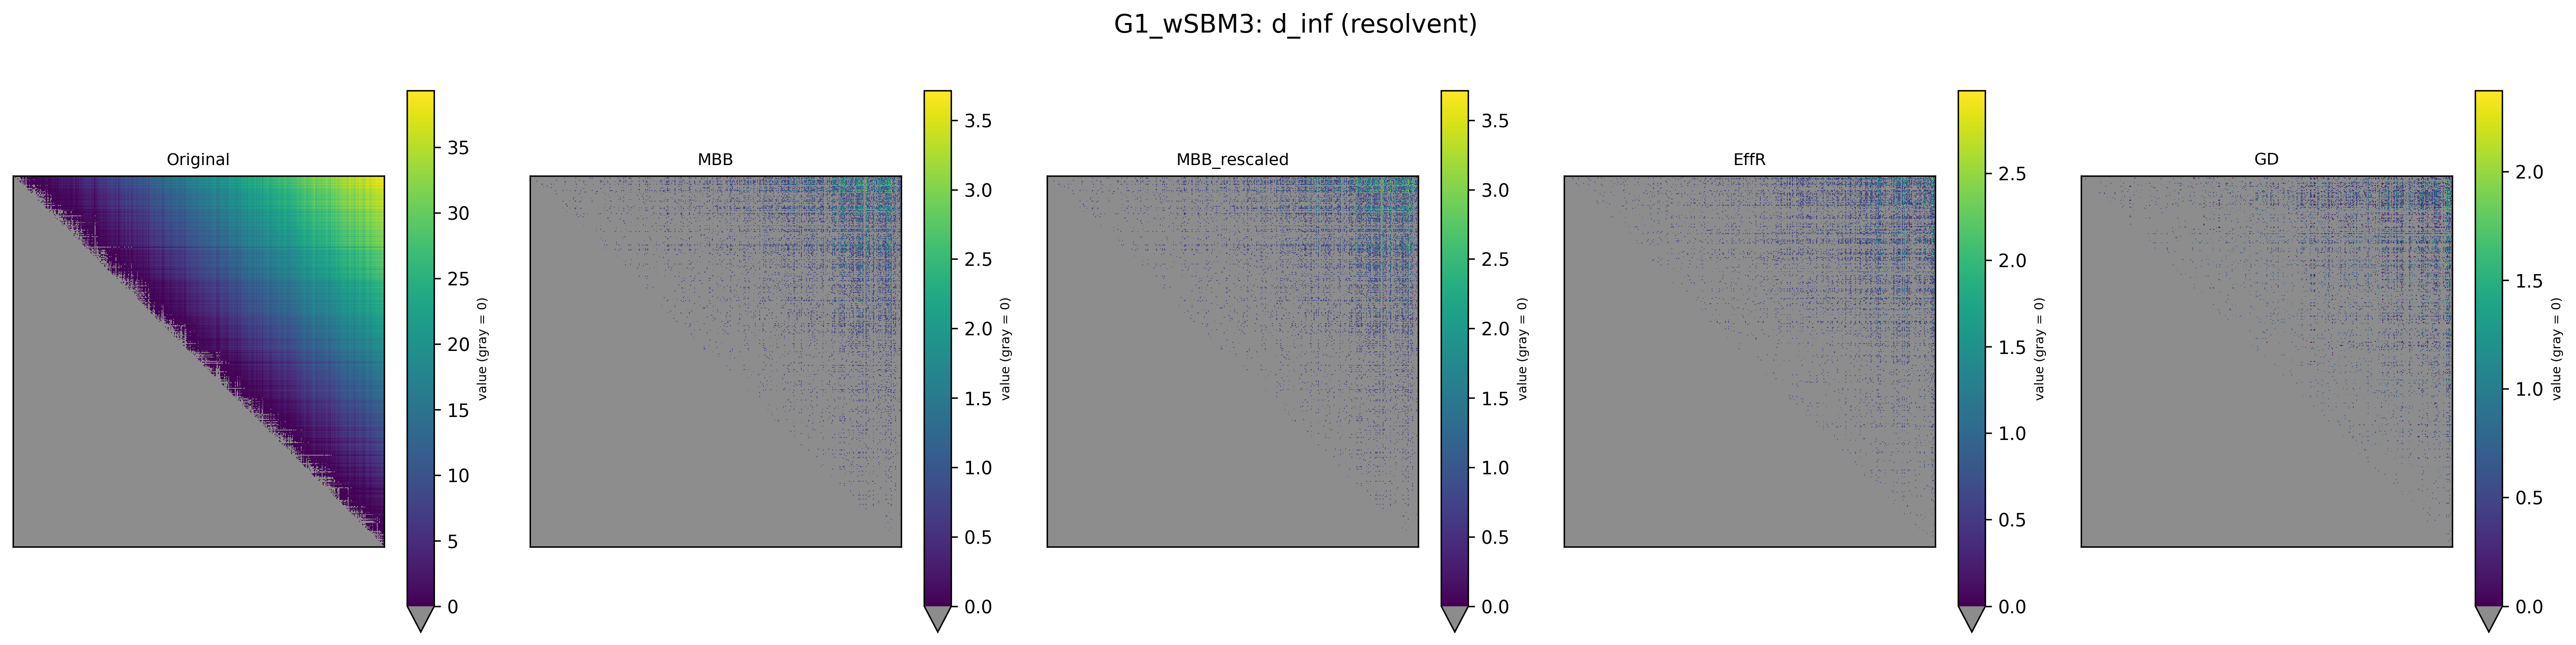

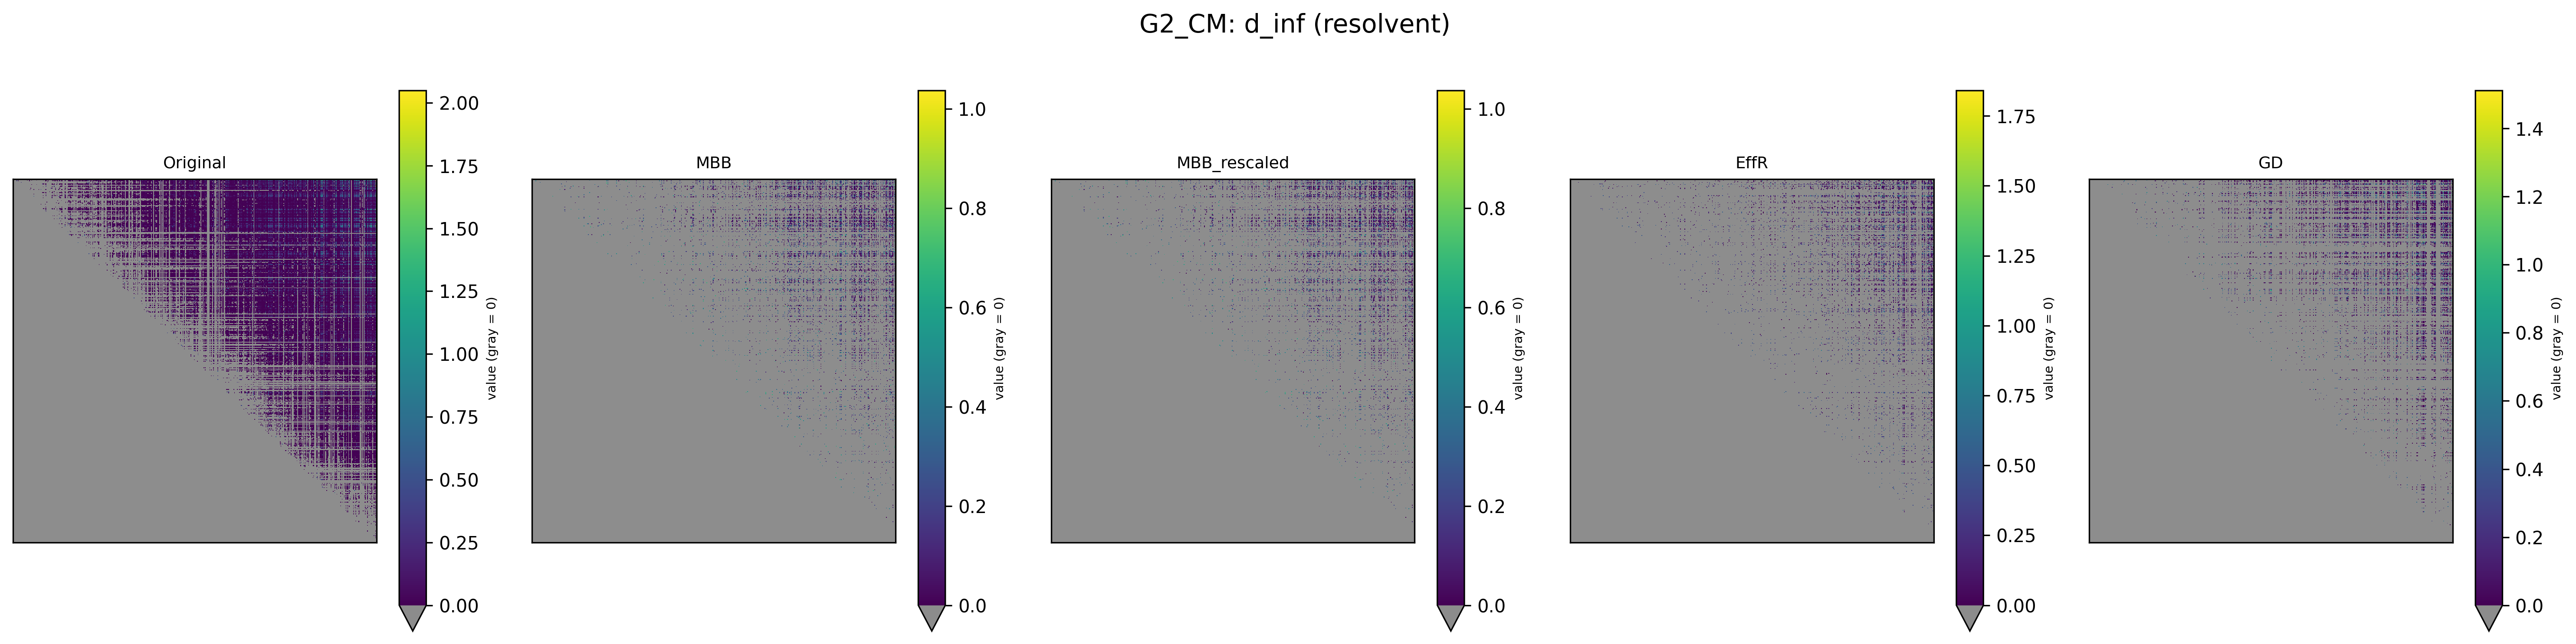

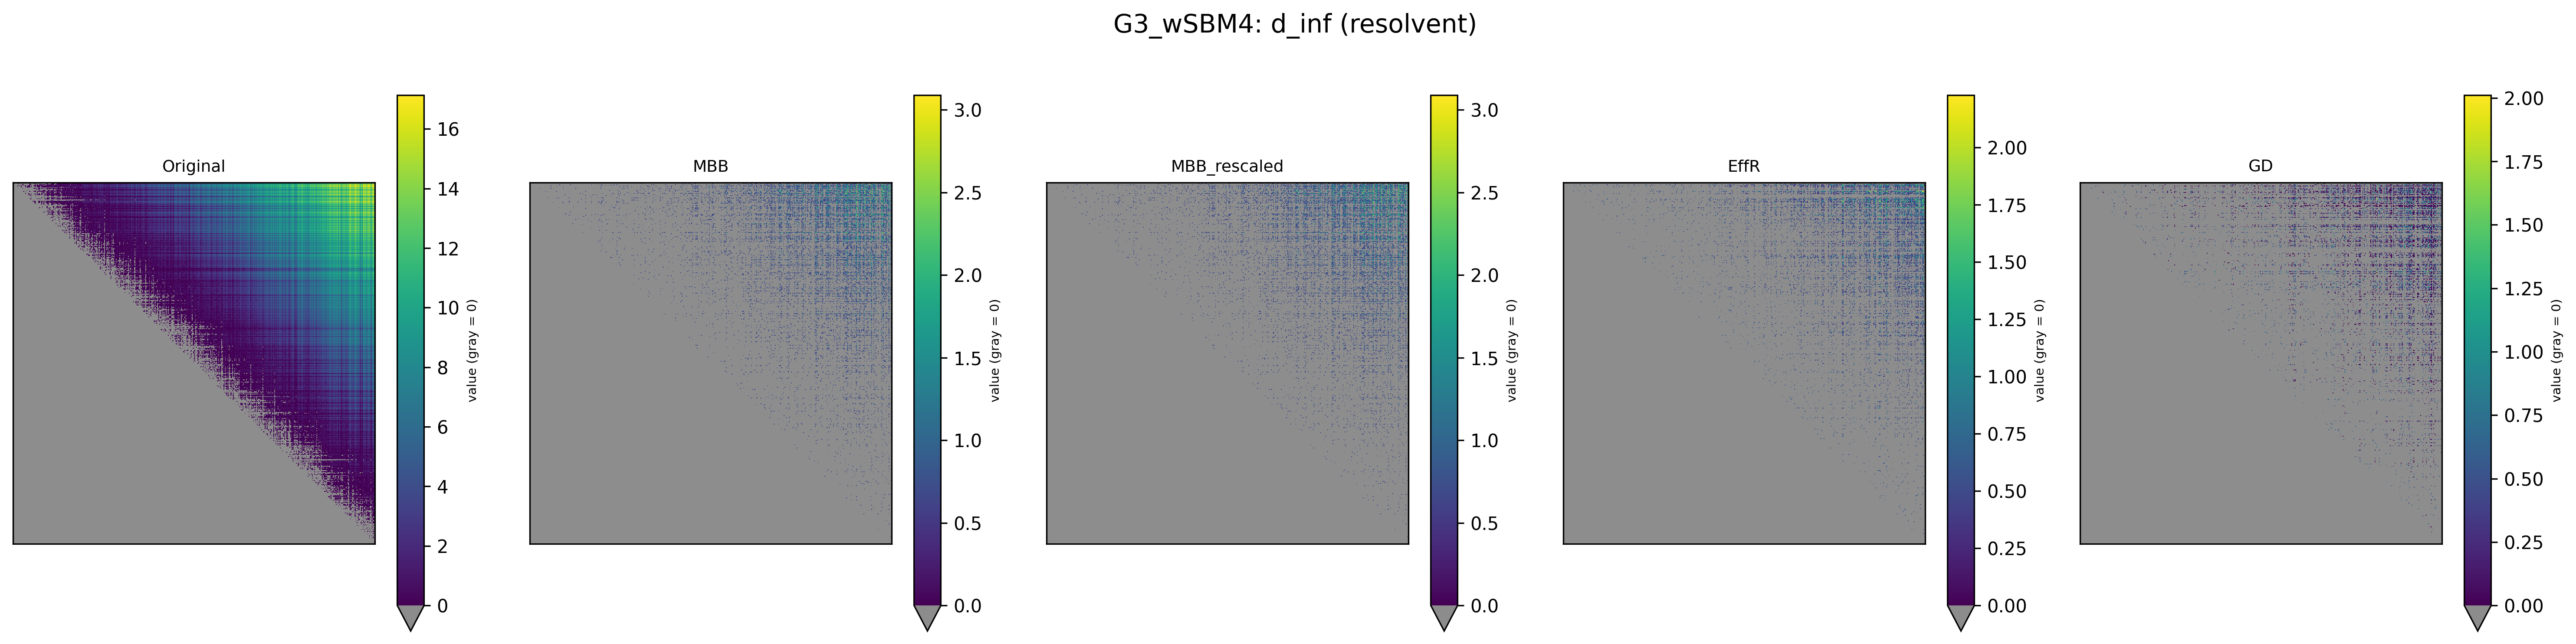

In [116]:
def graph_to_distance_tensor(G):
    d = np.array(G.get_adjacency(attribute="distance_weight", default=0).data, dtype=np.float64)
    return torch.tensor(d, dtype=torch.float64)


col_names = ["Original", "MBB", "MBB_rescaled", "EffR", "GD"]

all_matrices = {}
for gname, res in all_results.items():
    graphs_row = [
        res["G_orig"],
        res["pipeline"]["MBB"],
        res["pipeline"]["MBB_rescaled"],
        res["pipeline"]["EffR"],
        res["G_gd"],
    ]

    all_matrices[gname] = [
        compute_loss_matrix(graph_to_distance_tensor(G)).detach().numpy()
        for G in graphs_row
    ]

vmin = min(m.min() for row in all_matrices.values() for m in row)

for gname, matrices in all_matrices.items():
    plot_matrices(matrices, names=col_names, title=f"{gname}: d_inf (resolvent)", vmin=max(vmin, 1e-10))

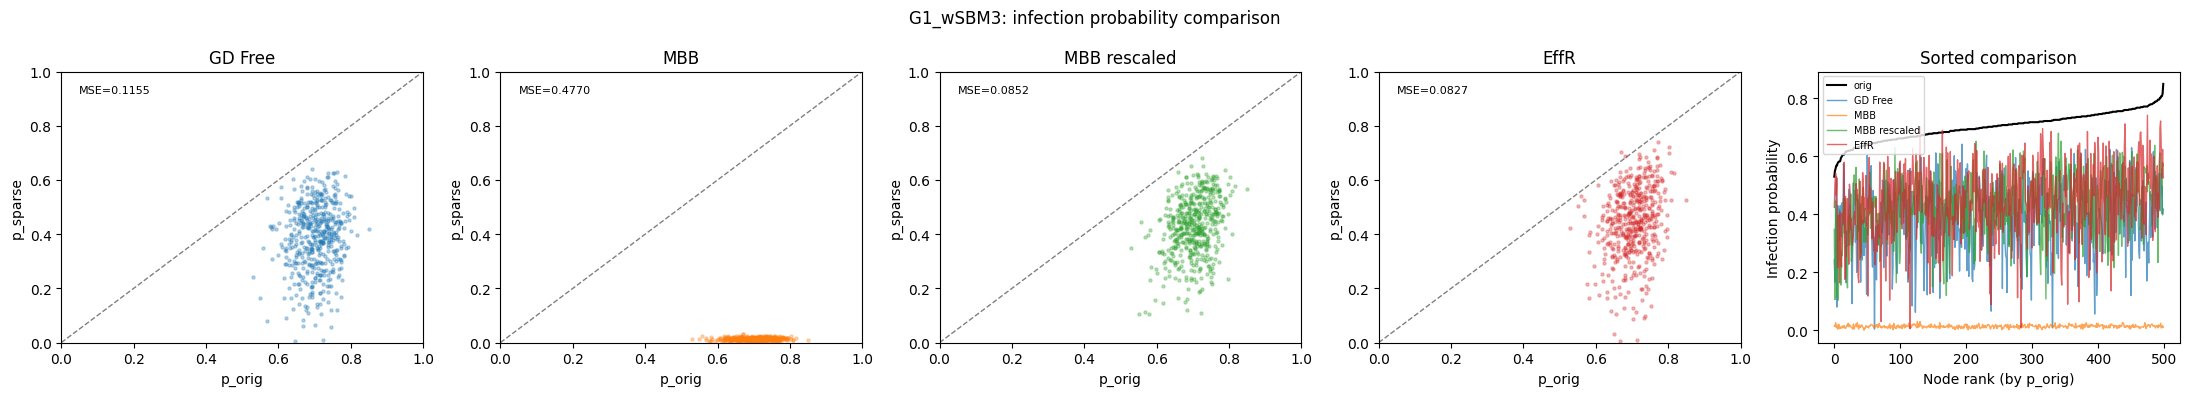

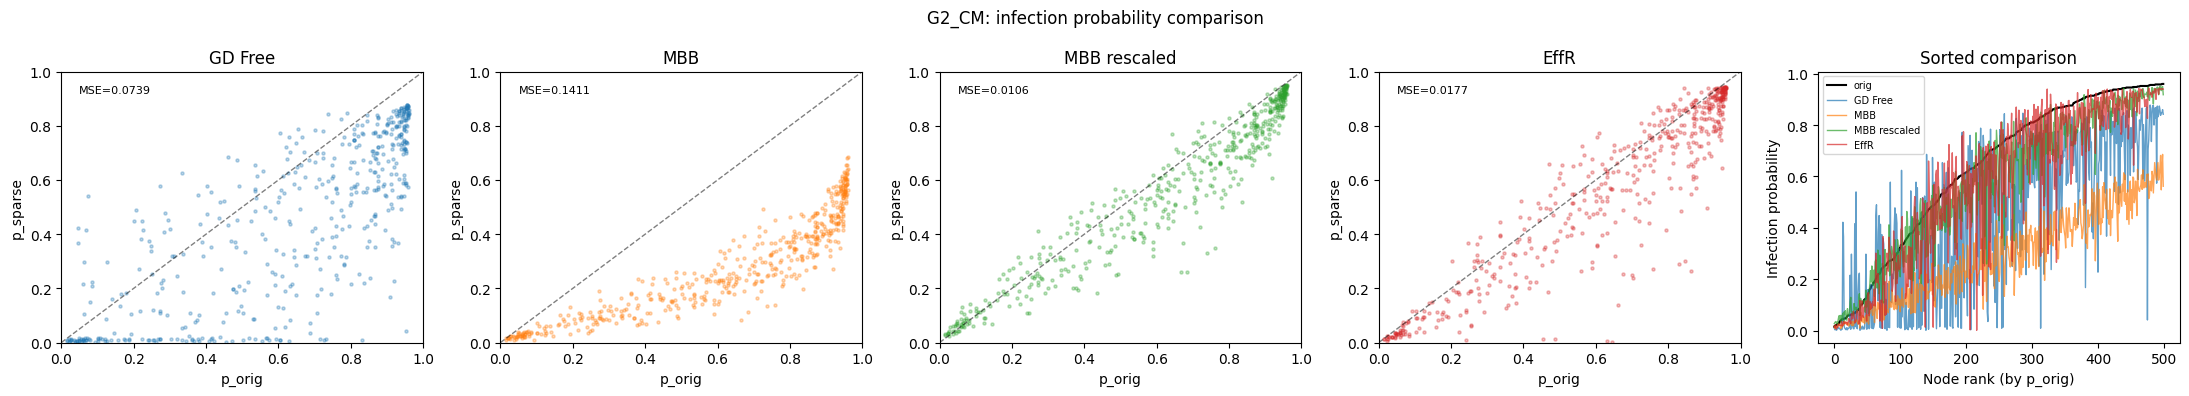

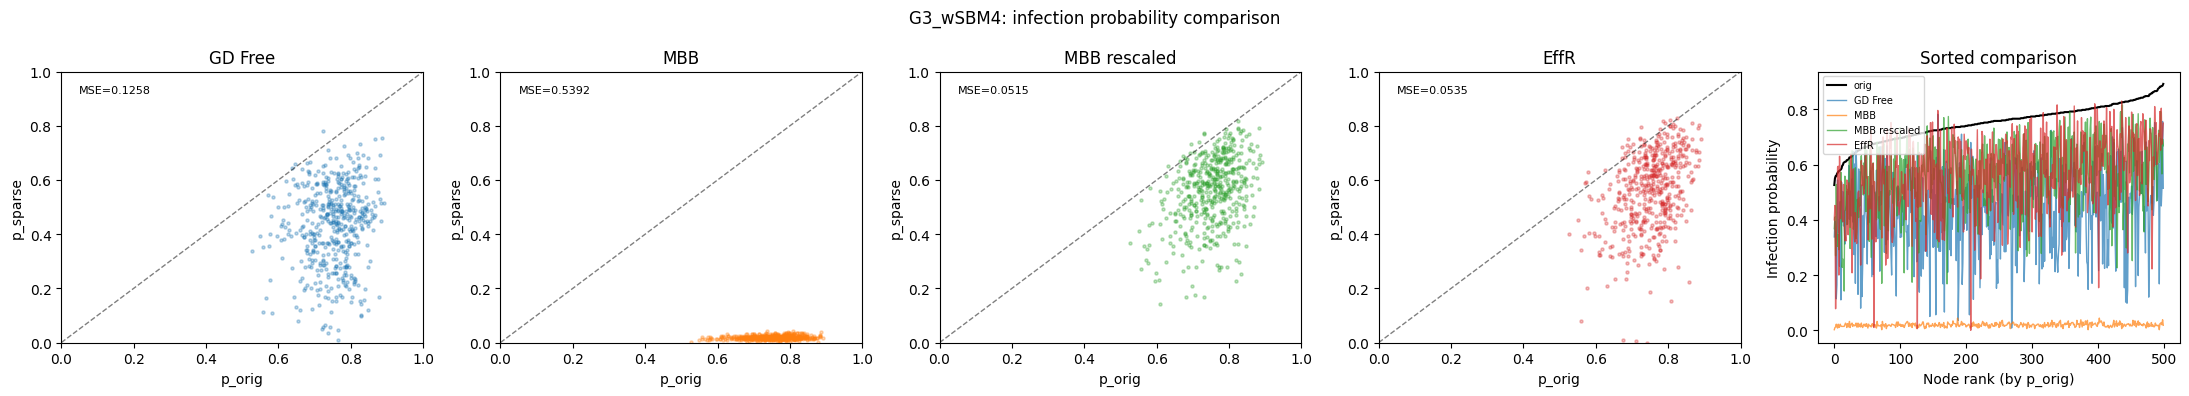

In [117]:
def plot_5way_comparison(p_orig, p_gd, p_mbb, p_mbb_rescaled, p_effr, title=""):
    """5-panel: 4 scatter plots (GD/MBB/MBB_rescaled/EffR vs orig) + 1 sorted line plot."""
    p_orig = np.array(p_orig)
    methods = [
        ("GD Free",      np.array(p_gd),           "tab:blue"),
        ("MBB",          np.array(p_mbb),           "tab:orange"),
        ("MBB rescaled", np.array(p_mbb_rescaled),  "tab:green"),
        ("EffR",         np.array(p_effr),          "tab:red"),
    ]
    fig, axes = plt.subplots(1, 5, figsize=(22, 4))

    for ax, (name, p_sparse, color) in zip(axes[:4], methods):
        ax.scatter(p_orig, p_sparse, alpha=0.3, s=5, color=color)
        ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
        ax.set_xlabel("p_orig"); ax.set_ylabel("p_sparse"); ax.set_title(name)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        mse, _ = compute_mse(p_orig, p_sparse)
        ax.text(0.05, 0.95, f"MSE={mse:.4f}", transform=ax.transAxes, fontsize=8, va="top")

    # Sorted line plot
    ax = axes[4]
    idx = np.argsort(p_orig)
    ax.plot(p_orig[idx], label="orig", color="black", lw=1.5)
    for name, p_sparse, color in methods:
        ax.plot(p_sparse[idx], label=name, color=color, alpha=0.7, lw=1)
    ax.set_xlabel("Node rank (by p_orig)"); ax.set_ylabel("Infection probability")
    ax.set_title("Sorted comparison"); ax.legend(fontsize=7)

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


for gname, res in all_results.items():
    pr = res["pipeline"]
    p_orig = np.array(pr["infection_probs"]["orig"])
    plot_5way_comparison(
        p_orig=p_orig,
        p_gd=np.array(res["p_gd"]),
        p_mbb=np.array(pr["infection_probs"]["MBB"]),
        p_mbb_rescaled=np.array(pr["infection_probs"]["MBB_rescaled"]),
        p_effr=np.array(pr["infection_probs"]["EffR"]),
        title=f"{gname}: infection probability comparison",
    )


## MSE summary table

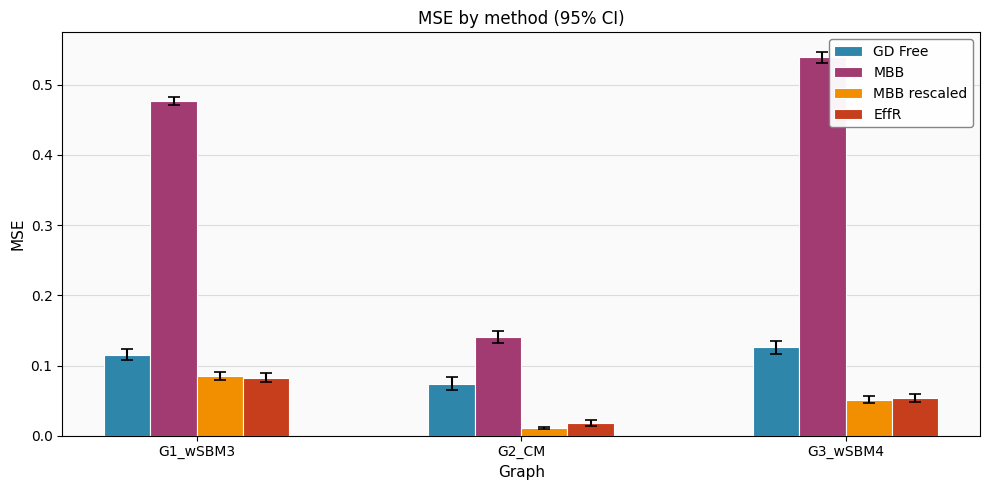

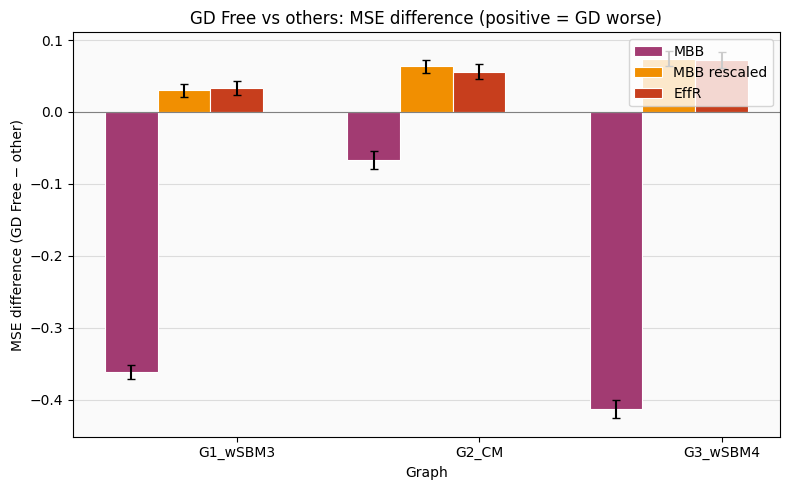

In [118]:
# MSE summary — bar chart with CI
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

methods = ["GD Free", "MBB", "MBB rescaled", "EffR"]
graphs = list(all_results.keys())
n_graphs = len(graphs)
n_methods = len(methods)
bar_width = 0.2
group_width = n_methods * bar_width + 0.1
x = np.arange(n_graphs) * (group_width + 0.5)

# Nicer color palette (muted, distinct)
colors = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"]  # blue, magenta, orange, red

for i, method in enumerate(methods):
    mse_vals = []
    err_lo = []
    err_hi = []
    for gname in graphs:
        res = all_results[gname]
        pr = res["pipeline"]
        if method == "GD Free":
            mse, ci = res["mse_gd"], res["mse_gd_CI"]
        elif method == "MBB":
            mse, ci = pr["mse_mbb"], pr["mse_mbb_CI"]
        elif method == "MBB rescaled":
            mse, ci = pr["mse_mbb_rescaled"], pr["mse_mbb_rescaled_CI"]
        else:
            mse, ci = pr["mse_effr"], pr["mse_effr_CI"]
        mse_vals.append(mse)
        err_lo.append(mse - ci[0])
        err_hi.append(ci[1] - mse)
    offset = (i - n_methods / 2 + 0.5) * bar_width
    bars = ax.bar(
        x + offset,
        mse_vals,
        bar_width,
        label=method,
        color=colors[i % len(colors)],
        edgecolor="white",
        linewidth=0.8,
        yerr=[err_lo, err_hi],
        capsize=4,
        error_kw=dict(elinewidth=1.5, capthick=1.2),
    )

ax.set_xticks(x)
ax.set_xticklabels(graphs)
ax.set_ylabel("MSE", fontsize=11)
ax.set_xlabel("Graph", fontsize=11)
ax.set_title("MSE by method (95% CI)", fontsize=12, fontweight="medium")
ax.legend(loc="upper right", framealpha=0.95, edgecolor="gray")
ax.set_yscale("linear")
ax.grid(True, axis="y", which="both", linestyle="-", alpha=0.4)
ax.set_axisbelow(True)
ax.set_facecolor("#FAFAFA")
for spine in ax.spines.values():
    spine.set_visible(True)
plt.tight_layout()
plt.show()

# GD Free vs others — difference (GD MSE - other MSE)
# Positive: GD has higher MSE (worse); Negative: GD has lower MSE (better)

fig, ax = plt.subplots(figsize=(8, 5))

others = ["MBB", "MBB rescaled", "EffR"]
colors = ["#A23B72", "#F18F01", "#C73E1D"]
x = np.arange(len(graphs))
bar_width = 0.25
group_width = 3 * bar_width + 0.1

for i, (other, c) in enumerate(zip(others, colors)):
    diffs = []
    err_lo = []
    err_hi = []
    for gname in graphs:
        res = all_results[gname]
        pr = res["pipeline"]
        gd_mse, gd_ci = res["mse_gd"], res["mse_gd_CI"]
        if other == "MBB":
            oth_mse, oth_ci = pr["mse_mbb"], pr["mse_mbb_CI"]
        elif other == "MBB rescaled":
            oth_mse, oth_ci = pr["mse_mbb_rescaled"], pr["mse_mbb_rescaled_CI"]
        else:
            oth_mse, oth_ci = pr["mse_effr"], pr["mse_effr_CI"]
        d = gd_mse - oth_mse
        diffs.append(d)
        # Approximate SE and CI of difference (uncertainty propagation)
        se_gd = (gd_ci[1] - gd_ci[0]) / 3.92
        se_oth = (oth_ci[1] - oth_ci[0]) / 3.92
        se_diff = np.sqrt(se_gd**2 + se_oth**2)
        err_lo.append(1.96 * se_diff)
        err_hi.append(1.96 * se_diff)
    offset = (i - 1) * bar_width
    ax.bar(x * (group_width + 0.3) + offset, diffs, bar_width, label=other, color=c,
           edgecolor="white", linewidth=0.8, yerr=[err_lo, err_hi], capsize=3)

ax.axhline(0, color="gray", linestyle="-", linewidth=0.8)
ax.set_xticks(x * (group_width + 0.3) + bar_width)
ax.set_xticklabels(graphs)
ax.set_ylabel("MSE difference (GD Free − other)")
ax.set_xlabel("Graph")
ax.set_title("GD Free vs others: MSE difference (positive = GD worse)")
ax.legend(loc="upper right")
ax.grid(True, axis="y", which="both", linestyle="-", alpha=0.4)
ax.set_axisbelow(True)
ax.set_facecolor("#FAFAFA")
plt.tight_layout()
plt.show()